In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from my_config import CONFIG
from data import MonteCarloEngine
from CV import CV
from VMC import payout
import time
from scipy.stats import norm

In [35]:
# VMC Estimates 
VMC={
    'Mean':[],
    'SE':[],
    'time':[]
}
CV_dict={
    'Mean':[],
    'SE':[],
    'time':[]
}
Y_VMC=[]
Y_CV=[]
for i in range(100):
    engine_start=time.time()
    data_engine_nonAV=MonteCarloEngine(
        N=CONFIG['N'],
        m=CONFIG["m"],
        n=CONFIG["n"],
        S0=np.array(CONFIG["S0"]),
        d=np.array(CONFIG["d"]),
        r=CONFIG["r"],
        corr_matrix=np.array(CONFIG["corr_matrix"]),
        sig=np.array(CONFIG["sig"]),
        IV=CONFIG["IV"],
        PA=CONFIG["PA"],
        days_trade_yr=CONFIG["days_trade_yr"],
        T_N=CONFIG["T_N"],
        t_c=CONFIG["t_c"],
        autocall_checkpt=np.array(CONFIG["autocall_checkpt"])
    )
    
    Z=data_engine_nonAV.simulate_Z()
    R=data_engine_nonAV.simulate_path(Z)
    U=data_engine_nonAV.simulate_U()
    autocheck_idx=data_engine_nonAV.checkpt_idx()
    barrier_bw=data_engine_nonAV.brownian_bridge(U)
    payout_engine_nonAV=payout(data_engine_nonAV)
    VMC_mean,VMC_SE,VMC_final=payout_engine_nonAV.execute()
    engine_stop=time.time()-engine_start
    CV_start=time.time()
    CV_engine=CV(data_engine_nonAV,payout_engine_nonAV,0.62)
    mean_CV,se_CV,Y_cv=CV_engine.execute()
    CV_stop=time.time()-CV_start
    VMC['Mean'].append(VMC_mean)
    CV_dict['Mean'].append(mean_CV)
    VMC['SE'].append(VMC_SE)
    CV_dict['SE'].append(se_CV)
    VMC['time'].append(engine_stop)
    CV_dict['time'].append(CV_stop+engine_stop)
    Y_VMC.append(VMC_final)
    Y_CV.append(Y_cv)
    
    
    

In [36]:
AV_dict={
    'Mean':[],
    'SE':[]
}
AVCV_dict={
    'Mean':[],
    'SE':[]
}
Y_AV=[]
Y_AVCV=[]
for i in range(100):
    engine_start=time.time()
    data_engine_AV=MonteCarloEngine(
        N=CONFIG['N_AV'],
        m=CONFIG["m"],
        n=CONFIG["n"],
        S0=np.array(CONFIG["S0"]),
        d=np.array(CONFIG["d"]),
        r=CONFIG["r"],
        corr_matrix=np.array(CONFIG["corr_matrix"]),
        sig=np.array(CONFIG["sig"]),
        IV=CONFIG["IV"],
        PA=CONFIG["PA"],
        days_trade_yr=CONFIG["days_trade_yr"],
        T_N=CONFIG["T_N"],
        t_c=CONFIG["t_c"],
        autocall_checkpt=np.array(CONFIG["autocall_checkpt"])
    )
    
    Z=data_engine_AV.simulate_Z()
    U=data_engine_AV.simulate_U()
    R_pos=data_engine_AV.simulate_path(Z)
    autocheck_idx=data_engine_AV.checkpt_idx()
    barrier_bw=data_engine_AV.brownian_bridge(U)
    S_N_pos=R_pos[:,-1,:]
    CV1_pos=S_N_pos*CONFIG['S0']*np.exp(CONFIG['r']*CONFIG['T_N'])
    CV2_pos=np.maximum(CONFIG['strike']-CONFIG['S0']*S_N_pos,0)
    X_pos=np.column_stack([
                CV1_pos,
                CV2_pos
        ])
    ECV1=CONFIG['S0']*np.exp(-CONFIG['d']*CONFIG['T_N'])
   
    d1=(np.log(CONFIG['S0']/CONFIG['strike'])+(CONFIG['r']-CONFIG['d']+0.5*CONFIG['sig_yearly']**2)*CONFIG['T_N'])/(CONFIG['sig_yearly']*np.sqrt(CONFIG['T_N']))
    d2=d1-CONFIG['sig_yearly']*np.sqrt(CONFIG['T_N'])
    ECV2=CONFIG['strike']*np.exp(CONFIG['r']*CONFIG['T_N'])*norm.cdf(-d2)-CONFIG['S0']*np.exp(CONFIG['d']*CONFIG['T_N'])*norm.cdf(-d1)
    ECV_pos=np.concatenate([ECV1,ECV2]).copy()
    payout_engine_AVP=payout(data_engine_AV)
    AVP_mean,AVP_SE,AVP_payout=payout_engine_AVP.execute()
    R_neg=data_engine_AV.simulate_path(-Z)
    payout_engine_AVN=payout(data_engine_AV)
    S_N_neg=R_neg[:,-1,:]
    CV1_neg=S_N_neg*CONFIG['S0']*np.exp(CONFIG['r']*CONFIG['T_N'])
    CV2_neg=np.maximum(CONFIG['strike']-CONFIG['S0']*S_N_neg,0)
    X_neg=np.column_stack([
                CV1_neg,
                CV2_neg
        ])
    AVN_mean,AVN_SE,AVN_payout=payout_engine_AVN.execute()
    AV_payout=0.5*(AVN_payout+AVP_payout)
    X_payout=0.5*(X_pos+X_neg)
    AV_payout_centered=AV_payout-AV_payout.mean()
    X_payout_centered=X_payout-X_payout.mean(axis=0)
    beta=np.linalg.lstsq(X_payout_centered,AV_payout_centered,rcond=None)[0]
    Y_CV=AV_payout-(X_payout-ECV_pos)@beta
    AV_mean=np.mean(AV_payout)
    AV_SE=np.std(AV_payout)/np.sqrt(CONFIG['N_AV'])
    AVCV_mean=np.mean(Y_CV)
    AVCV_SE=np.std(Y_CV)/np.sqrt(CONFIG['N_AV'])
    engine_stop=time.time()-engine_start
    AV_dict['Mean'].append(AV_mean)
    AV_dict['SE'].append(AV_SE)
    AVCV_dict['Mean'].append(AVCV_mean)
    AVCV_dict['SE'].append(AVCV_SE)
    

In [37]:
AV_dict

{'Mean': [1084.0052065165462,
  1083.8968422173714,
  1083.7135984960703,
  1083.7500215176929,
  1083.6763725412627,
  1083.8934526600174,
  1083.7009634760987,
  1083.8092201094476,
  1083.9188326315384,
  1083.824404476442,
  1084.114998058383,
  1083.9018390366953,
  1084.1465449660047,
  1083.632971275409,
  1083.9461482567528,
  1083.9821885721076,
  1083.953388134039,
  1083.8639396450692,
  1083.9448551679552,
  1083.8648631351587,
  1083.819527521143,
  1083.8878053921926,
  1083.8108372092336,
  1083.8364895017442,
  1083.821253307296,
  1083.929135610086,
  1083.9933421247035,
  1083.728732590995,
  1083.680111261691,
  1083.7760153119468,
  1083.8346258894574,
  1083.8822999517092,
  1083.774251654607,
  1083.8439358060493,
  1083.6703227388032,
  1083.8453150103605,
  1083.8343374304563,
  1083.5607780431328,
  1083.6726721571827,
  1083.7862504917698,
  1083.6515967186292,
  1084.1222518882525,
  1083.8821849064966,
  1083.8403901937777,
  1083.886111472247,
  1083.676856

In [38]:
AVCV_dict

{'Mean': [1083.319880300149,
  1083.793603040898,
  1084.385922324709,
  1083.9729542900704,
  1083.3765544691466,
  1083.4557435391885,
  1083.8137863980576,
  1083.973919144073,
  1084.0835222097007,
  1084.125321560615,
  1084.1077374006306,
  1084.0142505200783,
  1083.8611455609378,
  1083.4145157072003,
  1083.8902530411638,
  1084.2872680465312,
  1083.6548226350722,
  1083.8352888565853,
  1083.7726494429205,
  1083.4973345431056,
  1083.9860491409752,
  1083.2990009266225,
  1083.9475283145794,
  1083.2731089125166,
  1083.5983157202609,
  1083.210226611544,
  1083.7807428002936,
  1083.6746645487594,
  1084.0487187353544,
  1084.2445254338616,
  1083.7139268344392,
  1083.9309766175663,
  1084.3287511223668,
  1083.4903131248698,
  1083.5218533571092,
  1083.716279456345,
  1083.674090884433,
  1083.4513198680413,
  1083.7431793517092,
  1083.2667675311427,
  1083.2627860524383,
  1084.3277760425149,
  1083.4811754376888,
  1084.0855088710446,
  1084.3014901495428,
  1082.857

In [39]:
V_df=pd.DataFrame(VMC)
C_df=pd.DataFrame(CV_dict)
A_df=pd.DataFrame(AV_dict)
AC_df=pd.DataFrame(AVCV_dict)

In [41]:
V_df.describe()

,Mean,SE,time
count,100.000000,100.000000,100.000000
mean,1083.709392,0.151565,2.851291
std,0.147441,0.002822,0.084292
min,1083.238503,0.146402,2.723956
25%,1083.610095,0.149409,2.791203
50%,1083.710155,0.151402,2.831293
75%,1083.806962,0.153359,2.882867
max,1084.100123,0.159169,3.221316


In [42]:
C_df.describe()

,Mean,SE,time
count,100.000000,100.000000,100.000000
mean,1083.691250,0.114693,2.891893
std,0.120607,0.002335,0.087817
min,1083.357384,0.109091,2.764597
25%,1083.615508,0.113252,2.829405
50%,1083.692752,0.114669,2.870270
75%,1083.786946,0.116180,2.923167
max,1083.950615,0.122238,3.310348


In [43]:
A_df.describe()

,Mean,SE
count,100.000000,100.000000
mean,1083.825038,0.138235
std,0.124656,0.003160
min,1083.560778,0.129503
25%,1083.726070,0.136421
50%,1083.832467,0.138291
75%,1083.911132,0.140493
max,1084.146545,0.146116


In [44]:
AC_df.describe()

,Mean,SE
count,100.000000,100.000000
mean,1083.740717,0.101929
std,0.394596,0.001491
min,1082.747496,0.098873
25%,1083.480862,0.100678
50%,1083.787173,0.101850
75%,1084.049950,0.102825
max,1084.619082,0.105153


(array([ 1.,  2.,  3., 12., 20., 24., 21., 10.,  6.,  1.]),
 array([1083.23850302, 1083.32466505, 1083.41082708, 1083.49698911,
        1083.58315114, 1083.66931317, 1083.7554752 , 1083.84163723,
        1083.92779926, 1084.01396128, 1084.10012331]),
 <BarContainer object of 10 artists>)

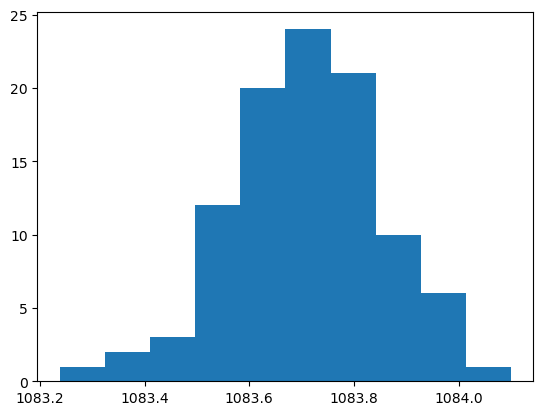

In [59]:
plt.hist(V_df.Mean,bins=10)

(array([ 2.,  3.,  7.,  7., 17., 18., 18., 16.,  8.,  4.]),
 array([1083.35738425, 1083.41670729, 1083.47603033, 1083.53535337,
        1083.59467642, 1083.65399946, 1083.7133225 , 1083.77264554,
        1083.83196859, 1083.89129163, 1083.95061467]),
 <BarContainer object of 10 artists>)

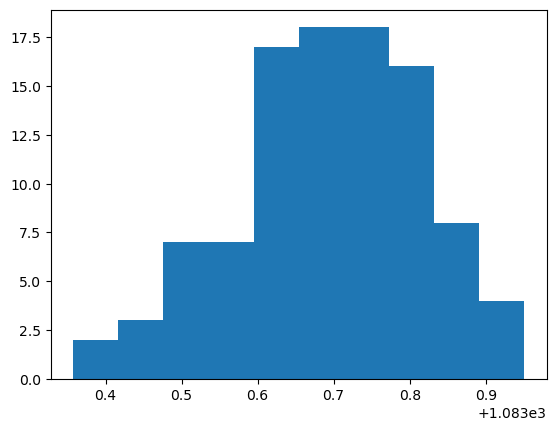

In [58]:
plt.hist(C_df.Mean,bins=10)

(array([ 1., 15., 13., 15., 15., 16., 13.,  7.,  2.,  3.]),
 array([1083.56077804, 1083.61935474, 1083.67793143, 1083.73650812,
        1083.79508481, 1083.8536615 , 1083.9122382 , 1083.97081489,
        1084.02939158, 1084.08796827, 1084.14654497]),
 <BarContainer object of 10 artists>)

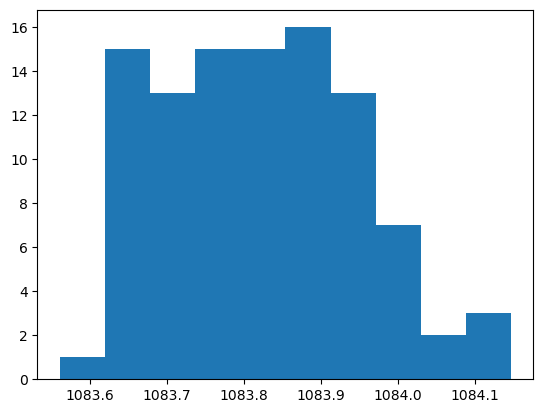

In [57]:
plt.hist(A_df.Mean,bins=10)

(array([ 3.,  3., 10., 12., 16., 14., 18., 16.,  6.,  2.]),
 array([1082.74749621, 1082.9346548 , 1083.1218134 , 1083.30897199,
        1083.49613059, 1083.68328918, 1083.87044778, 1084.05760637,
        1084.24476497, 1084.43192356, 1084.61908216]),
 <BarContainer object of 10 artists>)

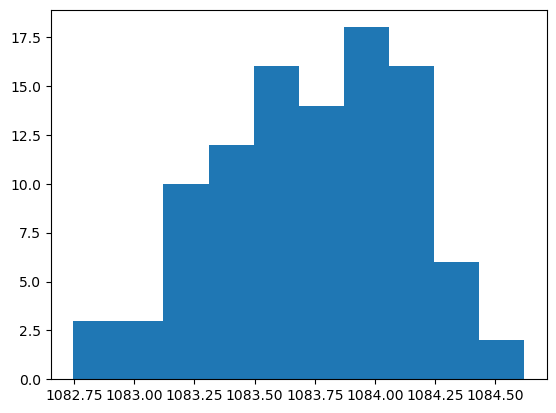

In [62]:
plt.hist(AC_df.Mean)

In [63]:
C_df

,Mean,SE,time
0,1083.795347,0.113943,3.310348
1,1083.797600,0.114023,3.111472
2,1083.842597,0.113373,2.992157
3,1083.600036,0.117399,2.967736
4,1083.799601,0.113369,2.842227
...,...,...,...
95,1083.709755,0.115299,2.870999
96,1083.804754,0.114140,3.007562
97,1083.677033,0.112796,2.918886
98,1083.766018,0.110418,2.939313


In [71]:
for i in range(1):
    data_engine=MonteCarloEngine(
                    N=CONFIG["N"],
                    m=CONFIG["m"],
                    n=CONFIG["n"],
                    S0=np.array(CONFIG["S0"]),
                    d=np.array(CONFIG["d"]),
                    r=CONFIG["r"],
                    corr_matrix=np.array(CONFIG["corr_matrix"]),
                    sig=np.array(CONFIG["sig"]),
                    IV=CONFIG["IV"],
                    PA=CONFIG["PA"],
                    days_trade_yr=CONFIG["days_trade_yr"],
                    T_N=CONFIG["T_N"],
                    t_c=CONFIG["t_c"],
                    autocall_checkpt=np.array(CONFIG["autocall_checkpt"])
                )
    Z=data_engine.simulate_Z()
    U=data_engine.simulate_U()
    R=data_engine.simulate_path(Z)
    check_idx=data_engine.checkpt_idx()
    brownian_bw=data_engine.brownian_bridge(U)
    payout_engine=payout(data_engine)
    payout_engine.execute()
    CV_engine=CV(data_engine,payout_engine,0.62)
    cv=CV_engine.cv()
        # print('SE & mean of cv',cv.std(axis=0),cv.mean(axis=0))
    ecv=CV_engine.ecv()
        # print('H mean',(cv-ecv).mean(axis=0))
    betas=CV_engine.beta_cal()
        # print('beta',betas)
    mean, se, Y_cv=CV_engine.apply_cv()
    print(mean,se)

1083.481041061441 0.11340870872890252


1083.5437108259782 0.11693563126754172


In [3]:
import numpy as np
import pandas as pd
from data import MonteCarloEngine
from my_config import CONFIG
from VMC import payout
from CV import CV
from scipy.stats import norm

for i in range(20):
    data_engine=MonteCarloEngine(
                N=CONFIG["N"],
                m=CONFIG["m"],
                n=CONFIG["n"],
                S0=np.array(CONFIG["S0"]),
                d=np.array(CONFIG["d"]),
                r=CONFIG["r"],
                corr_matrix=np.array(CONFIG["corr_matrix"]),
                sig=np.array(CONFIG["sig"]),
                IV=CONFIG["IV"],
                PA=CONFIG["PA"],
                days_trade_yr=CONFIG["days_trade_yr"],
                T_N=CONFIG["T_N"],
                t_c=CONFIG["t_c"],
                autocall_checkpt=np.array(CONFIG["autocall_checkpt"])
            )
    Z=data_engine.simulate_Z()
    U=data_engine.simulate_U()
    R=data_engine.simulate_path(Z)
    check_idx=data_engine.checkpt_idx()
    brownian_bw=data_engine.brownian_bridge(U)
    payout_engine=payout(data_engine)
    payout_engine.execute()
    CV_engine=CV(data_engine,payout_engine,0.62)
    cv=CV_engine.cv()
    # print('SE & mean of cv',cv.std(axis=0),cv.mean(axis=0))
    ecv=CV_engine.ecv()
    # print('H mean',(cv-ecv).mean(axis=0))
    betas=CV_engine.beta_cal()
    # print('beta',betas)
    mean, se, Y_cv=CV_engine.execute()
    print(mean,se)

1083.650549325945 0.025966619591477558
1083.653991050358 0.025625032862943882


KeyboardInterrupt: 

In [3]:
data_engine=MonteCarloEngine(
                N=CONFIG["N"],
                m=CONFIG["m"],
                n=CONFIG["n"],
                S0=np.array(CONFIG["S0"]),
                d=np.array(CONFIG["d"]),
                r=CONFIG["r"],
                corr_matrix=np.array(CONFIG["corr_matrix"]),
                sig=np.array(CONFIG["sig"]),
                IV=CONFIG["IV"],
                PA=CONFIG["PA"],
                days_trade_yr=CONFIG["days_trade_yr"],
                T_N=CONFIG["T_N"],
                t_c=CONFIG["t_c"],
                autocall_checkpt=np.array(CONFIG["autocall_checkpt"]
                                          ))

In [5]:
data_engine=MonteCarloEngine(
                N=CONFIG["N"],
                m=CONFIG["m"],
                n=CONFIG["n"],
                S0=np.array(CONFIG["S0"]),
                d=np.array(CONFIG["d"]),
                r=CONFIG["r"],
                corr_matrix=np.array(CONFIG["corr_matrix"]),
                sig=np.array(CONFIG["sig"]),
                IV=CONFIG["IV"],
                PA=CONFIG["PA"],
                days_trade_yr=CONFIG["days_trade_yr"],
                T_N=CONFIG["T_N"],
                t_c=CONFIG["t_c"],
                autocall_checkpt=np.array(CONFIG["autocall_checkpt"]
                                          ))
VMC_dict={
    'Mean':[],
    'SE':[]
}
CV_dict={
    'Mean':[],
    'SE':[]
}
for i in range(100):
    data_engine.execute()
    payout_engine=payout(data_engine)
    payout_engine.execute()
    CV_engine=CV(data_engine,payout_engine,0.62)
    CV_engine.execute()
    VMC_dict['Mean'].append(payout_engine.mean)
    CV_dict['Mean'].append(CV_engine.mean)
    VMC_dict['SE'].append(payout_engine.SE)
    CV_dict['SE'].append(CV_engine.se)

In [ ]:
data_engine_AV=MonteCarloEngine(
                N=CONFIG["N_AV"],
                m=CONFIG["m"],
                n=CONFIG["n"],
                S0=np.array(CONFIG["S0"]),
                d=np.array(CONFIG["d"]),
                r=CONFIG["r"],
                corr_matrix=np.array(CONFIG["corr_matrix"]),
                sig=np.array(CONFIG["sig"]),
                IV=CONFIG["IV"],
                PA=CONFIG["PA"],
                days_trade_yr=CONFIG["days_trade_yr"],
                T_N=CONFIG["T_N"],
                t_c=CONFIG["t_c"],
                autocall_checkpt=np.array(CONFIG["autocall_checkpt"]
                                          ))
for i in range(2):
    Z=data_engine_AV.simulate_Z()
    U=data_engine_AV.simulate_U()
    check_idx=data_engine_AV.checkpt_idx()
    RP=data_engine_AV.simulate_path(Z)
    data_engine_AV.brownian_bridge(U)
    payout_pos=payout(data_engine_AV)
    meanP,SEP,payoutP=payout_pos.execute()
    
    RN=data_engine_AV.simulate_path(-Z)
    data_engine_AV.brownian_bridge(U)
    payout_neg=payout(data_engine_AV)
    meanN,SEN,payoutN=payout_neg.execute()
    
    X=0.5*(payoutP+payoutN)
    print('+ve',meanP,SEP)
    print('-ve',meanN,SEN)
    print('AV mean',np.mean(X))
    print('AV SE',np.std(X)/np.sqrt(len(X)))
    
    

+ve 1083.6284399468775 0.047824469532567616
-ve 1083.6284399468775 0.047824469532567616
AV mean 1083.6284399468775
AV SE 0.04782446953256761
+ve 1083.667947909327 0.04813085080410626
-ve 1083.667947909327 0.04813085080410626
AV mean 1083.667947909327
AV SE 0.04813085080410626
